In [17]:
import numpy as np
import matplotlib.pyplot as plt
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegularizationSetting, RegSolver
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.tikhonov import TikhonovCG
from regpy.solvers.linear.primal_dual import PDHG
from regpy.solvers.nonlinear.fista import FISTA
import regpy.functionals as fct
from regpy.hilbert import L2
from regpy.stoprules import CountIterations
import logging

# Deconvolution with impulsive noise
We set up a 1D periodic deconvolution problem with impulsive noise. 
If we solve this problem by Tikhonov regularization with a quadratic data fidelity term, then the reconstruction is dominated by the effects of this impulsive noise. 

2024-06-25 16:41:45,468 INFO TikhonovCG           :: it.19 kappa=1.0238928156911962 err/Tol rel X:5.1e-07/1.0e-06 
2024-06-25 16:41:45,470 INFO TikhonovCG           :: Solver converged after 19 iteration.


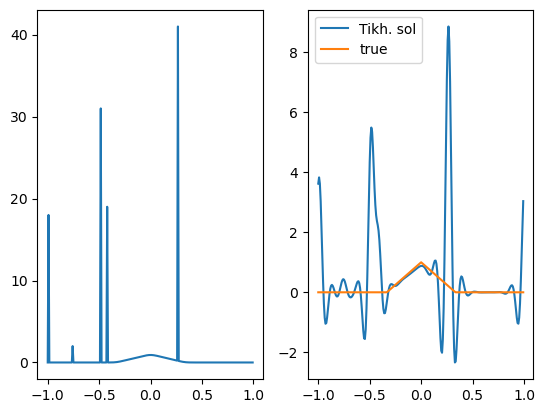

In [18]:
n = 256
sigma = 0.02
alpha = 0.1
grid = UniformGridFcts((-1,1,n),periodic=True)
conv = GaussianBlur(grid,kernel_width=0.05)

x = grid.coords[0]
fdag = np.maximum(0,1-3*np.abs(x))
gobs = conv(fdag)

for j in range(5):
    k = np.random.randint(n)
    gobs[k] = np.random.randint(50)

setting = RegularizationSetting(conv,L2,L2)
solver = TikhonovCG(setting=setting, data = gobs, regpar = alpha,reltolx=1e-6)
fal,_ = solver.run()

fig, (ax1,ax2) =plt.subplots(1,2)
ax1.plot(x,gobs)
ax2.plot(x,fal,label='Tikh. sol')
ax2.plot(x,fdag,label='true')
ax2.legend()

# setting with Huber data fidelity term
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_f\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

Moreover, we set up three solvers for this setting:
- FISTA
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method
- Semismooth Newton method


In [19]:
Sdat = (1./sigma)*fct.Huber(grid,sigma=sigma)
huber_setting = TikhonovRegularizationSetting(conv,L2,Sdat,alpha,data_fid_shift=gobs)
dual_setting = huber_setting.dualSetting()

solverFISTA = FISTA(dual_setting,logging_level=logging.DEBUG)
solverPDHG = PDHG(huber_setting,logging_level=logging.DEBUG)
solverSS = SemismoothNewton_bilateral(dual_setting,cgpar={'reltolx':1e-6,'tol':1e-6},logging_level=logging.DEBUG)
itPDHG = iter(solverPDHG)
itFISTA = iter(solverFISTA)

2024-06-25 16:41:45,994 INFO FISTA                :: Set up FISTA with convexity parameters mu_R=2.000e-03, mu_S=0.000e+00 and step length tau=1.000e+00.
 Expected linear convergence rate: 9.553e-01
2024-06-25 16:41:46,000 INFO FISTA                :: initial duality gap: 1.191069024817814
2024-06-25 16:41:46,136 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=2.000e-03 and ||T||=1.000e+00.
 Expected linear convergence rate: 9.179e-01
2024-06-25 16:41:46,930 INFO TikhonovCG           :: it.613 kappa=2.8812383757051405 err/Tol abs X: 2.0e-02/2.2e-02
2024-06-25 16:41:46,931 INFO TikhonovCG           :: Solver converged after 613 iteration.
2024-06-25 16:41:46,934 DEBUG SemismoothNewton_bilateral :: it 0: CG its 613; changes active sets +256.0,-0


# FISTA
Run this cell until the duality gap is sufficiently small. 

In [32]:
for j in range(20):
    p_FISTA,Tstar_pFISTA = next(itFISTA)
f_FISTA = huber_setting.dualToPrimal(Tstar_pFISTA,argumentIsOperatorImage=True)
"""
fig, (ax1,ax2) = plt.subplots(1,2)
ax1.plot(p_FISTA,label = 'p_FISTA')
ax1.legend()
ax2.plot(f_FISTA,label='f_FISTA')
ax2.legend()
"""
print('it=',solverFISTA.iteration_step_nr,'duality gap:', huber_setting.dualityGap(dual=p_FISTA))

2024-06-25 16:42:31,893 DEBUG FISTA                :: it.81: duality gap=2.684e-06
2024-06-25 16:42:31,900 DEBUG FISTA                :: it.82: duality gap=2.568e-06
2024-06-25 16:42:31,906 DEBUG FISTA                :: it.83: duality gap=2.333e-06
2024-06-25 16:42:31,912 DEBUG FISTA                :: it.84: duality gap=2.627e-06
2024-06-25 16:42:31,917 DEBUG FISTA                :: it.85: duality gap=2.103e-06
2024-06-25 16:42:31,923 DEBUG FISTA                :: it.86: duality gap=inf
2024-06-25 16:42:31,928 DEBUG FISTA                :: it.87: duality gap=1.923e-06
2024-06-25 16:42:31,939 DEBUG FISTA                :: it.88: duality gap=1.986e-06
2024-06-25 16:42:31,944 DEBUG FISTA                :: it.89: duality gap=inf
2024-06-25 16:42:31,954 DEBUG FISTA                :: it.90: duality gap=1.102e-06
2024-06-25 16:42:31,962 DEBUG FISTA                :: it.91: duality gap=1.383e-06
2024-06-25 16:42:31,970 DEBUG FISTA                :: it.92: duality gap=8.777e-07
2024-06-25 16:42

it= 100 duality gap: inf


# PDHG
Run this cell until the duality gap is sufficiently small. 

In [28]:
for j in range(20):
    f_PDHG,p_PDHG = next(itPDHG)
"""
fig, (ax1,ax2) = plt.subplots(1,2)
ax1.plot(p_PDHG,label = 'p_PDHG')
ax1.legend()
ax2.plot(f_PDHG,label='f_PDHG')
ax2.legend()
"""
print('it:',solverPDHG.iteration_step_nr,'duality gap:',huber_setting.dualityGap(primal=f_PDHG))


2024-06-25 16:42:19,836 DEBUG PDHG                 :: it. 101: duality gap=7.492e-08
2024-06-25 16:42:19,843 DEBUG PDHG                 :: it. 102: duality gap=8.464e-08
2024-06-25 16:42:19,850 DEBUG PDHG                 :: it. 103: duality gap=1.056e-07
2024-06-25 16:42:19,857 DEBUG PDHG                 :: it. 104: duality gap=1.317e-07
2024-06-25 16:42:19,864 DEBUG PDHG                 :: it. 105: duality gap=1.574e-07
2024-06-25 16:42:19,872 DEBUG PDHG                 :: it. 106: duality gap=1.785e-07
2024-06-25 16:42:19,878 DEBUG PDHG                 :: it. 107: duality gap=1.922e-07
2024-06-25 16:42:19,886 DEBUG PDHG                 :: it. 108: duality gap=1.972e-07
2024-06-25 16:42:19,896 DEBUG PDHG                 :: it. 109: duality gap=1.934e-07
2024-06-25 16:42:19,908 DEBUG PDHG                 :: it. 110: duality gap=1.819e-07
2024-06-25 16:42:19,915 DEBUG PDHG                 :: it. 111: duality gap=1.645e-07
2024-06-25 16:42:19,920 DEBUG PDHG                 :: it. 112: du

it: 120 duality gap: 1.9040127294256415e-08


# Semismooth Newton method

The method gives a solution that looks better than those of FISTA and PDHG, but the duality gap is much larger. 
(Possibly the effective regularization parameter is wrong!)

In [34]:
p_SS,Tstar_pSS = solverSS.run(stoprule=CountIterations(50))
f_SS    = huber_setting.dualToPrimal(Tstar_pSS,argumentIsOperatorImage=True)
print('SSNewton duality gap - from dual:', huber_setting.dualityGap(dual=p_SS), 
      'from primal', huber_setting.dualityGap(primal=f_SS))

2024-06-25 17:04:29,310 INFO CountIterations      :: iteration = 1 / 50
2024-06-25 17:04:29,311 INFO SemismoothNewton_bilateral :: Solver converged after 26 iteration.


SSNewton duality gap - from dual: 0.08681935163298701 from primal 0.23920659752357676


# Plot results of all methods for comparison

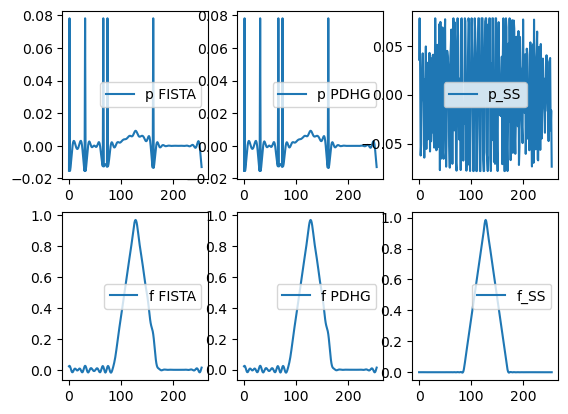

In [33]:
fig,((ax11,ax12,ax13),(ax21,ax22,ax23)) = plt.subplots(2,3)

ax11.plot(p_FISTA,label='p FISTA'); ax11.legend()
ax12.plot(solverPDHG.pstar,label='p PDHG');   ax12.legend()
ax13.plot(p_SS, label = 'p_SS');     ax13.legend()

ax21.plot(f_FISTA,label='f FISTA'); ax21.legend()
ax22.plot(f_PDHG,label='f PDHG');   ax22.legend()
ax23.plot(f_SS, label = 'f_SS');     ax23.legend()